/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1, Loss: 0.7309
Epoch 2, Loss: 0.7062
Epoch 3, Loss: 0.5885
Epoch 4, Loss: 0.5414
Epoch 5, Loss: 0.4648
Training Complete
Accuracy: 0.4


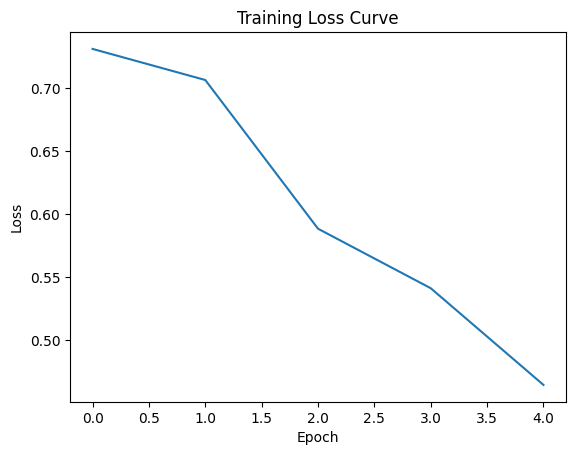

In [1]:
# ==============================
# LAB 7: BERT (IMPROVED)
# ==============================

!pip install transformers torch scikit-learn matplotlib

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ------------------------------
# 1. BETTER DATASET (MORE SAMPLES)
# ------------------------------
texts = [
    "Stock market is rising today",
    "The company reported huge losses",
    "AI is transforming industries",
    "This product is terrible",
    "I love this new technology",
    "This is the worst experience ever",
    "The results are very positive",
    "I am not happy with the service",
    "Amazing performance by the model",
    "Bad quality and poor design"
]

labels = torch.tensor([1,0,1,0,1,0,1,0,1,0])

# ------------------------------
# 2. TOKENIZATION
# ------------------------------
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

# Dataset + DataLoader
dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], labels)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# ------------------------------
# 3. MODEL
# ------------------------------
model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# ------------------------------
# 4. TRAINING LOOP
# ------------------------------
losses = []
model.train()

for epoch in range(5):   # more epochs → lower loss
    total_loss = 0

    for batch in loader:
        input_ids, attention_mask, y = batch

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=y)

        loss = outputs.loss
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

print("Training Complete")

# ------------------------------
# 5. EVALUATION
# ------------------------------
model.eval()
preds = []

with torch.no_grad():
    for batch in loader:
        input_ids, attention_mask, y = batch
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds.extend(torch.argmax(logits, dim=1).tolist())

accuracy = accuracy_score(labels, preds)
print("Accuracy:", accuracy)

# ------------------------------
# 6. LOSS VISUALIZATION
# ------------------------------
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()